# 🔬 DCT Replication via CNN — Block-wise Learning

Train a CNN to replicate DCT on 8×8 patches. Ground truth = true DCT coefficients. CNN learns the transform via backprop.

In [6]:
import os, glob, warnings, time
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from scipy.fftpack import dct, idct

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device: {device}")
print(f"📦 PyTorch: {torch.__version__}")


✅ Device: cpu
📦 PyTorch: 2.11.0+cpu


In [7]:
# ============================================================
# CONFIGURATION  — edit only here, everything else auto-follows
# ============================================================
CONFIG = {
    'train_path'  : r'C:\Users\nandi\Desktop\Additional_project\dataset\train',
    'test_path'   : r'C:\Users\nandi\Desktop\Additional_project\dataset\test',
    'img_size'    : 128,    # resize images to this square
    'block_size'  : 8,      # DCT block (JPEG standard)
    'batch_size'  : 512,
    'epochs'      : 60,
    'learning_rate': 3e-4,
    'weight_decay': 1e-5,
    'num_workers' : 0,      # keep 0 on Windows
    'dct_quality' : 50,
}

print("⚙️  Config:")
for k, v in CONFIG.items():
    print(f"   {k}: {v}")


⚙️  Config:
   train_path: C:\Users\nandi\Desktop\Additional_project\dataset\train
   test_path: C:\Users\nandi\Desktop\Additional_project\dataset\test
   img_size: 128
   block_size: 8
   batch_size: 512
   epochs: 60
   learning_rate: 0.0003
   weight_decay: 1e-05
   num_workers: 0
   dct_quality: 50


In [8]:
# ============================================================
# DCT / IDCT HELPERS
# ============================================================
def dct2(block):
    return dct(dct(block.T, norm='ortho').T, norm='ortho')

def idct2(block):
    return idct(idct(block.T, norm='ortho').T, norm='ortho')

def get_quant_table(quality=50):
    Q_base = np.array([
        [16,11,10,16,24,40,51,61],
        [12,12,14,19,26,58,60,55],
        [14,13,16,24,40,57,69,56],
        [14,17,22,29,51,87,80,62],
        [18,22,37,56,68,109,103,77],
        [24,35,55,64,81,104,113,92],
        [49,64,78,87,103,121,120,101],
        [72,92,95,98,112,100,103,99],
    ], dtype=np.float32)
    scale = 5000/quality if quality < 50 else 200 - 2*quality
    return np.floor((Q_base*scale+50)/100).clip(min=1)

def compress_dct_image(image, quality=50):
    """Full-image JPEG-style DCT compression. image in [0,1], returns [0,1]."""
    img = image * 255.0
    h, w = img.shape
    ph = (8-h%8)%8; pw = (8-w%8)%8
    padded = np.pad(img, ((0,ph),(0,pw)), mode='edge')
    Q = get_quant_table(quality)
    out = np.zeros_like(padded)
    for i in range(0, padded.shape[0], 8):
        for j in range(0, padded.shape[1], 8):
            b = padded[i:i+8, j:j+8]
            out[i:i+8, j:j+8] = idct2(np.round(dct2(b)/Q)*Q).clip(0, 255)
    return (out[:h, :w] / 255.0).clip(0, 1)

print("✅ DCT helpers ready")


✅ DCT helpers ready


In [9]:
# ============================================================
# PATCH DATASET
# x = raw 8x8 patch pixels [-1,1]   shape (1,8,8)
# y = mean+std normalised DCT coeffs shape (64,)
#
# WHY mean+std, not just std?
#   The DC coefficient has mean ~4.0 (for [0,1] patches).
#   std-only normalisation gives DC a y_norm mean of ~13.8,
#   forcing the model to output a large constant for just one
#   frequency — MSE loss handles this very badly.
#   mean+std centres every coefficient at zero, making the
#   regression task uniform across all 64 frequencies.
# ============================================================
class PatchDCTDataset(Dataset):
    def __init__(self, root_dir, img_size=128, block=8,
                 coeff_mean=None, coeff_std=None):
        self.block = block
        exts = ['*.png','*.jpg','*.jpeg','*.bmp','*.tif']
        paths = []
        for e in exts:
            paths.extend(glob.glob(os.path.join(root_dir, '**', e), recursive=True))
        if not paths:
            raise ValueError(f"❌ No images found in: {root_dir}")
        print(f"  Found {len(paths)} images — extracting {block}×{block} patches …")

        patches_x, patches_y = [], []
        for p in tqdm(paths, desc='Loading'):
            img = np.array(
                Image.open(p).convert('L').resize((img_size, img_size), Image.LANCZOS),
                dtype=np.float32) / 255.0
            for i in range(0, img_size - block + 1, block):
                for j in range(0, img_size - block + 1, block):
                    patch = img[i:i+block, j:j+block]
                    patches_x.append((patch * 2.0 - 1.0).astype(np.float32))
                    patches_y.append(dct2(patch).astype(np.float32).ravel())

        self.x = np.stack(patches_x)   # (N, 8, 8)
        self.y = np.stack(patches_y)   # (N, 64)  raw DCT coeffs in [0,1] space

        # mean+std normalisation — compute from data or inherit from train set
        if coeff_mean is None:
            self.coeff_mean = self.y.mean(axis=0)           # (64,)
            self.coeff_std  = self.y.std(axis=0).clip(1e-6) # (64,)
        else:
            self.coeff_mean = coeff_mean
            self.coeff_std  = coeff_std

        self.y_norm = (self.y - self.coeff_mean) / self.coeff_std  # zero-mean, unit-var

        print(f"  Patches : {len(self.x):,}  x={self.x.shape}  y_norm={self.y_norm.shape}")
        print(f"  y_norm  : mean={self.y_norm.mean():.5f}  std={self.y_norm.std():.5f}  "
              f"(should be ~0 and ~1)")
        print(f"  DC coeff: mean={self.coeff_mean[0]:.4f}  std={self.coeff_std[0]:.4f}")

    def __len__(self): return len(self.x)

    def __getitem__(self, idx):
        return (torch.from_numpy(self.x[idx]).unsqueeze(0),  # (1,8,8)
                torch.from_numpy(self.y_norm[idx]))           # (64,)


print("\n📦 Building datasets …\n")
train_ds = PatchDCTDataset(CONFIG['train_path'], CONFIG['img_size'], CONFIG['block_size'])
# test set inherits train statistics so scales are identical
test_ds  = PatchDCTDataset(CONFIG['test_path'],  CONFIG['img_size'], CONFIG['block_size'],
                           coeff_mean=train_ds.coeff_mean,
                           coeff_std =train_ds.coeff_std)

train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'],
                          shuffle=True,  num_workers=CONFIG['num_workers'],
                          pin_memory=(device.type=='cuda'))
test_loader  = DataLoader(test_ds,  batch_size=CONFIG['batch_size'],
                          shuffle=False, num_workers=CONFIG['num_workers'],
                          pin_memory=(device.type=='cuda'))

print(f"\n✅ Train: {len(train_ds):,} patches  ({len(train_loader)} batches)")
print(f"✅ Test : {len(test_ds):,}  patches  ({len(test_loader)} batches)")



📦 Building datasets …

  Found 1502 images — extracting 8×8 patches …


Loading: 100%|██████████| 1502/1502 [00:11<00:00, 133.19it/s]


  Patches : 384,512  x=(384512, 8, 8)  y_norm=(384512, 64)
  y_norm  : mean=-0.00001  std=1.00019  (should be ~0 and ~1)
  DC coeff: mean=1.8802  std=1.4941
  Found 215 images — extracting 8×8 patches …


Loading: 100%|██████████| 215/215 [00:01<00:00, 139.55it/s]


  Patches : 55,040  x=(55040, 8, 8)  y_norm=(55040, 64)
  y_norm  : mean=0.00007  std=0.99953  (should be ~0 and ~1)
  DC coeff: mean=1.8802  std=1.4941

✅ Train: 384,512 patches  (751 batches)
✅ Test : 55,040  patches  (108 batches)


In [10]:
# ============================================================
# MODEL  —  (1,8,8) -> (64,)
# ============================================================
class DCTReplicationNet(nn.Module):
    def __init__(self, block=8):
        super().__init__()
        n = block * block   # 64
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.GELU(),
            nn.Conv2d(32, 64, 3, padding=1), nn.GELU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.GELU(),
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*n, 256), nn.GELU(),
            nn.Linear(256, 128),  nn.GELU(),
            nn.Linear(128, n),
        )
    def forward(self, x):
        return self.fc(self.conv(x))

model = DCTReplicationNet(CONFIG['block_size']).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"✅ DCTReplicationNet  |  {n_params:,} parameters")


✅ DCTReplicationNet  |  1,145,728 parameters


In [6]:
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(),
                        lr=CONFIG['learning_rate'],
                        weight_decay=CONFIG['weight_decay'])
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG['epochs'])
print(f"✅ Optimizer: AdamW   lr={CONFIG['learning_rate']}")


✅ Optimizer: AdamW   lr=0.0003


In [7]:
# ============================================================
# TRAINING LOOP
# ============================================================
def run_epoch(loader, training=True):
    model.train() if training else model.eval()
    total = 0.0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for x, y in tqdm(loader, desc='Train' if training else 'Val ', leave=False):
            x, y = x.to(device), y.to(device)
            loss = criterion(model(x), y)
            if training:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            total += loss.item()
    return total / len(loader)

history = {'train': [], 'val': []}
best_val = float('inf')
t0 = time.time()

print("\n" + "="*65)
print("               TRAINING  (DCT Replication)")
print("="*65)

for epoch in range(1, CONFIG['epochs']+1):
    tl = run_epoch(train_loader, True)
    vl = run_epoch(test_loader,  False)
    scheduler.step()
    history['train'].append(tl)
    history['val'].append(vl)

    flag = ''
    if vl < best_val:
        best_val = vl
        # Save as plain lists — avoids PyTorch 2.6 pickle restriction on numpy arrays
        torch.save({
            'epoch'      : epoch,
            'model'      : model.state_dict(),
            'coeff_mean' : train_ds.coeff_mean.tolist(),
            'coeff_std'  : train_ds.coeff_std.tolist(),
        }, 'best_dct_rep.pth')
        flag = '  ✅ saved'

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{CONFIG['epochs']}  |  "
              f"train={tl:.6f}  val={vl:.6f}{flag}")

print(f"\n✅ Done in {(time.time()-t0)/60:.1f} min  |  best val MSE = {best_val:.6f}")



               TRAINING  (DCT Replication)


Epoch   1/60  |  train=0.217867  val=0.003625  ✅ saved


Epoch   5/60  |  train=0.001343  val=0.000734  ✅ saved


Epoch  10/60  |  train=0.000745  val=0.000656


Epoch  15/60  |  train=0.000507  val=0.000207  ✅ saved


...

Epoch  40/60  |  train=0.000048  val=0.000059


Epoch  45/60  |  train=0.000025  val=0.000022  ✅ saved


Epoch  50/60  |  train=0.000011  val=0.000013


Epoch  55/60  |  train=0.000007  val=0.000007  ✅ saved


Epoch  60/60  |  train=0.000005  val=0.000006  ✅ saved

✅ Done in 259.4 min  |  best val MSE = 0.000006


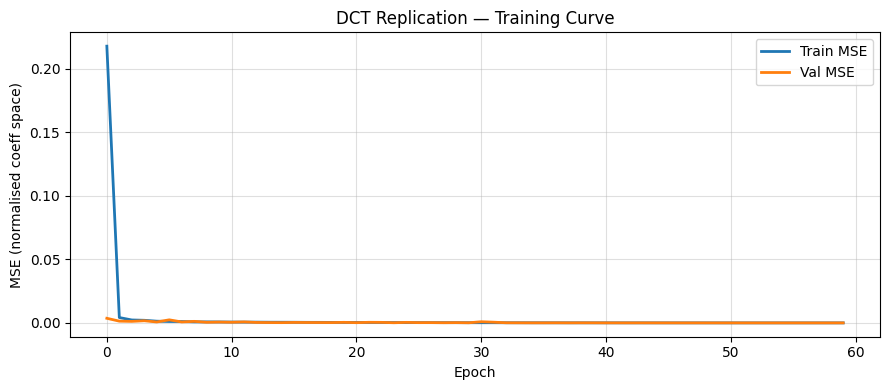

✅ training_curve.png saved


In [8]:
plt.figure(figsize=(9,4))
plt.plot(history['train'], label='Train MSE', linewidth=2)
plt.plot(history['val'],   label='Val MSE',   linewidth=2)
plt.xlabel('Epoch'); plt.ylabel('MSE (normalised coeff space)')
plt.title('DCT Replication — Training Curve')
plt.legend(); plt.grid(True, alpha=.4); plt.tight_layout()
plt.savefig('training_curve.png', dpi=150); plt.show()
print("✅ training_curve.png saved")


In [13]:
# ============================================================
# LOAD BEST CHECKPOINT
# ============================================================
ckpt       = torch.load('best_dct_rep.pth', map_location=device, weights_only=False)
model.load_state_dict(ckpt['model'])
model.eval()

coeff_mean = np.array(ckpt['coeff_mean'], dtype=np.float32)  # (64,)
coeff_std  = np.array(ckpt['coeff_std'],  dtype=np.float32)  # (64,)

print(f"✅ Loaded best model  (epoch {ckpt['epoch']})")
print(f"   coeff_mean: DC={coeff_mean[0]:.4f}  overall_mean={coeff_mean.mean():.4f}")
print(f"   coeff_std : DC={coeff_std[0]:.4f}   overall_mean={coeff_std.mean():.4f}")


✅ Loaded best model  (epoch 60)
   coeff_mean: DC=1.8802  overall_mean=0.0291
   coeff_std : DC=1.4941   overall_mean=0.1134


In [12]:
# ============================================================
# METRIC HELPERS
# ============================================================
def calc_psnr(a, b):
    mse = np.mean((a.astype(np.float64) - b.astype(np.float64))**2)
    return 60.0 if mse < 1e-10 else 20*np.log10(1.0/np.sqrt(mse))

def calc_ssim(a, b):
    C1, C2 = 0.01**2, 0.03**2
    mu1, mu2 = a.mean(), b.mean()
    s1, s2   = a.var(),  b.var()
    s12 = ((a-mu1)*(b-mu2)).mean()
    num = (2*mu1*mu2+C1)*(2*s12+C2)
    den = (mu1**2+mu2**2+C1)*(s1+s2+C2)
    return num/den if den != 0 else 1.0

# ============================================================
# RECONSTRUCTION FUNCTIONS
# ============================================================
def reconstruct_cnn(img_np, block=8):
    """
    Slide CNN over every 8x8 block.
    img_np : float32 [0,1]  shape (H,W)
    returns: float32 [0,1]  shape (H,W)

    Normalisation reversal:
      dataset stored:  y_norm = (coeff - coeff_mean) / coeff_std
      so to recover:   coeff  = y_norm_pred * coeff_std + coeff_mean
    """
    H, W = img_np.shape
    out = np.zeros_like(img_np)
    model.eval()
    with torch.no_grad():
        for i in range(0, H - block + 1, block):
            for j in range(0, W - block + 1, block):
                patch = img_np[i:i+block, j:j+block]

                # model input: pixels in [-1, 1]
                px = torch.from_numpy(
                    (patch * 2.0 - 1.0).astype(np.float32)
                ).unsqueeze(0).unsqueeze(0).to(device)    # (1,1,8,8)

                # model output: normalised DCT coeffs
                y_pred = model(px).cpu().numpy().ravel()  # (64,) normalised

                # de-normalise: reverse (coeff - mean) / std
                coeff = y_pred * coeff_std + coeff_mean   # (64,) raw coeffs

                # IDCT: coeffs are in [0,1]-patch space → IDCT returns [0,1]
                rec = idct2(coeff.reshape(block, block))
                out[i:i+block, j:j+block] = np.clip(rec, 0, 1)
    return out

def reconstruct_true_dct(img_np, block=8):
    """Lossless DCT round-trip. img_np in [0,1], returns [0,1]."""
    H, W = img_np.shape
    out = np.zeros_like(img_np)
    for i in range(0, H - block + 1, block):
        for j in range(0, W - block + 1, block):
            patch = img_np[i:i+block, j:j+block]
            out[i:i+block, j:j+block] = np.clip(idct2(dct2(patch)), 0, 1)
    return out

print("✅ Metric helpers and reconstruction functions ready")
print("   De-normalisation: coeff = y_pred * coeff_std + coeff_mean")


✅ Metric helpers and reconstruction functions ready
   De-normalisation: coeff = y_pred * coeff_std + coeff_mean


In [14]:
# ============================================================
# QUANTITATIVE EVALUATION  —  test set
# ============================================================
import glob
import os
exts = ['*.png','*.jpg','*.jpeg','*.bmp','*.tif']
test_paths = []
for e in exts:
    test_paths.extend(
        glob.glob(os.path.join(CONFIG['test_path'], '**', e), recursive=True)
    )

print(f"Found {len(test_paths)} test images in: {CONFIG['test_path']}")
if len(test_paths) == 0:
    raise FileNotFoundError(
        f"No test images found! Check CONFIG['test_path'] = {CONFIG['test_path']!r}"
    )

results = {k: {'psnr':[], 'ssim':[]} for k in ['true_dct','cnn_dct','jpg_dct']}
B = CONFIG['block_size']

for p in tqdm(test_paths, desc='Evaluating'):
    orig = np.array(
        Image.open(p).convert('L').resize(
            (CONFIG['img_size'], CONFIG['img_size']), Image.LANCZOS),
        dtype=np.float32) / 255.0

    # crop to exact multiple of block so every pixel is covered
    H8 = (orig.shape[0]//B)*B
    W8 = (orig.shape[1]//B)*B
    orig_c = orig[:H8, :W8]

    rec_true = reconstruct_true_dct(orig_c, B)
    rec_cnn  = reconstruct_cnn(orig_c, B)
    rec_jpg  = compress_dct_image(orig_c, CONFIG['dct_quality'])[:H8, :W8]

    for tag, rec in [('true_dct', rec_true),
                     ('cnn_dct',  rec_cnn),
                     ('jpg_dct',  rec_jpg)]:
        results[tag]['psnr'].append(calc_psnr(orig_c, rec))
        results[tag]['ssim'].append(calc_ssim(orig_c, rec))

print("\n" + "="*70)
print(" "*18 + "EVALUATION RESULTS")
print("="*70)
print(f"{'Method':<25} {'PSNR (dB)':>12}  {'SSIM':>8}")
print("-"*70)
for tag, label in [('true_dct','True DCT (lossless)'),
                   ('jpg_dct', f'JPEG-DCT Q={CONFIG["dct_quality"]}'),
                   ('cnn_dct', 'CNN DCT Replication')]:
    p_  = np.mean(results[tag]['psnr'])
    s_  = np.mean(results[tag]['ssim'])
    print(f"{label:<25} {p_:>12.4f}  {s_:>8.6f}")
print("="*70)
cnn_p  = np.mean(results['cnn_dct']['psnr'])
true_p = np.mean(results['true_dct']['psnr'])
jpg_p  = np.mean(results['jpg_dct']['psnr'])
print(f"\n📊 CNN vs true DCT : {cnn_p-true_p:+.3f} dB")
print(f"📊 CNN vs JPEG-DCT : {cnn_p-jpg_p:+.3f} dB")


Found 215 test images in: C:\Users\nandi\Desktop\Additional_project\dataset\test


Evaluating:   0%|          | 0/215 [00:00<?, ?it/s]

Evaluating: 100%|██████████| 215/215 [00:58<00:00,  3.66it/s]


                  EVALUATION RESULTS
Method                       PSNR (dB)      SSIM
----------------------------------------------------------------------
True DCT (lossless)            60.0000  1.000000
JPEG-DCT Q=50                  31.0915  0.991203
CNN DCT Replication            67.1621  0.999998

📊 CNN vs true DCT : +7.162 dB
📊 CNN vs JPEG-DCT : +36.071 dB


Coeff fidelity: 100%|██████████| 108/108 [00:03<00:00, 31.95it/s]


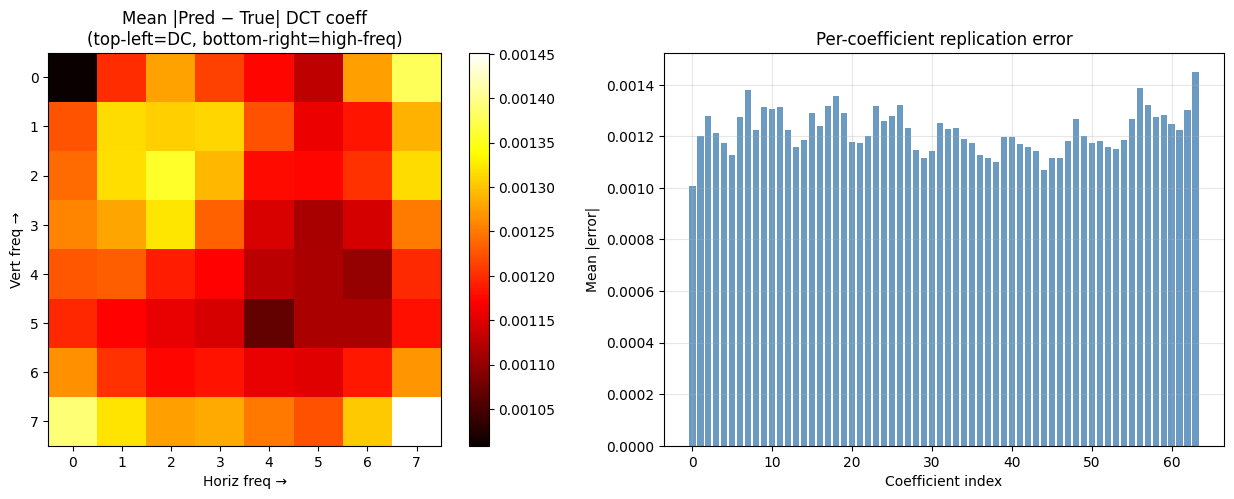

📊 DC error (idx 0):   0.00101
📊 Mean all 64 coeffs: 0.00122
📊 Worst coeff error:  0.00145 @ idx 63


In [15]:
# ============================================================
# COEFFICIENT-LEVEL FIDELITY  (on full test patch set)
# ============================================================
abs_errors = np.zeros(64, dtype=np.float64)
count = 0
model.eval()
with torch.no_grad():
    for x, y_norm in tqdm(test_loader, desc='Coeff fidelity'):
        pred = model(x.to(device)).cpu().numpy()
        true = y_norm.numpy()
        abs_errors += np.abs(pred - true).mean(axis=0)
        count += 1
abs_errors /= count

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
im = axes[0].imshow(abs_errors.reshape(8,8), cmap='hot', interpolation='nearest')
axes[0].set_title('Mean |Pred − True| DCT coeff\n(top-left=DC, bottom-right=high-freq)')
axes[0].set_xlabel('Horiz freq →'); axes[0].set_ylabel('Vert freq →')
plt.colorbar(im, ax=axes[0])
axes[1].bar(range(64), abs_errors, color='steelblue', alpha=.8)
axes[1].set_xlabel('Coefficient index'); axes[1].set_ylabel('Mean |error|')
axes[1].set_title('Per-coefficient replication error'); axes[1].grid(True, alpha=.3)
plt.tight_layout()
plt.savefig('coefficient_fidelity.png', dpi=150); plt.show()
print(f"📊 DC error (idx 0):   {abs_errors[0]:.5f}")
print(f"📊 Mean all 64 coeffs: {abs_errors.mean():.5f}")
print(f"📊 Worst coeff error:  {abs_errors.max():.5f} @ idx {abs_errors.argmax()}")


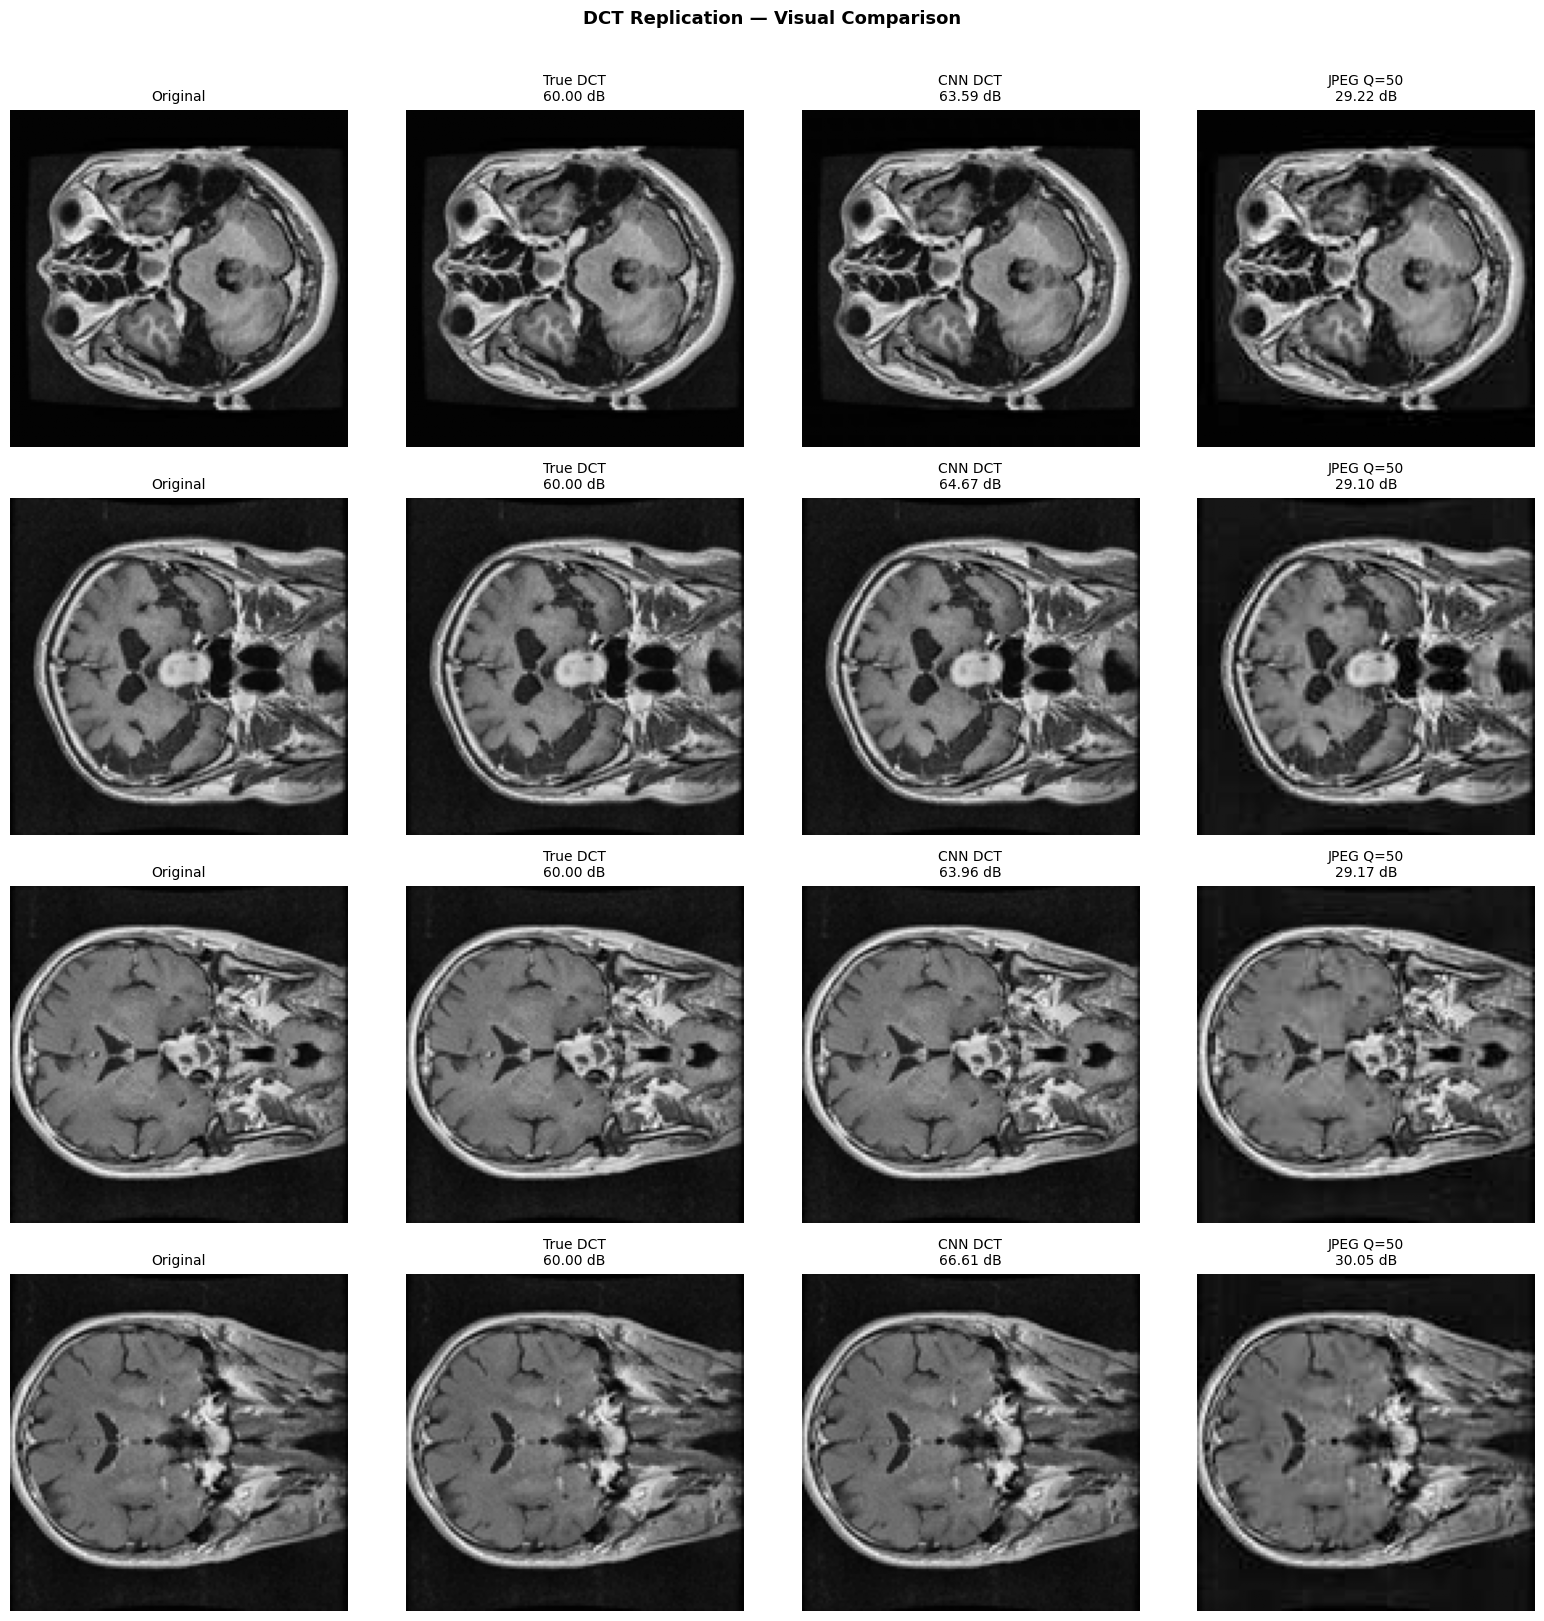

✅ visual_comparison.png saved


In [16]:
# ============================================================
# VISUAL COMPARISON  (up to 4 test images)
# ============================================================
sample_paths = test_paths[:4]
n = len(sample_paths)
B = CONFIG['block_size']

fig, axes = plt.subplots(n, 4, figsize=(16, 4*n))
if n == 1: axes = axes[None, :]

for row, p in enumerate(sample_paths):
    orig = np.array(
        Image.open(p).convert('L').resize(
            (CONFIG['img_size'], CONFIG['img_size']), Image.LANCZOS),
        dtype=np.float32) / 255.0
    H8 = (orig.shape[0]//B)*B; W8 = (orig.shape[1]//B)*B
    orig_c = orig[:H8, :W8]

    rec_true = reconstruct_true_dct(orig_c, B)
    rec_cnn  = reconstruct_cnn(orig_c, B)
    rec_jpg  = compress_dct_image(orig_c, CONFIG['dct_quality'])[:H8, :W8]

    for col, (im_, t_) in enumerate(zip(
        [orig_c, rec_true, rec_cnn, rec_jpg],
        ['Original',
         f'True DCT\n{calc_psnr(orig_c,rec_true):.2f} dB',
         f'CNN DCT\n{calc_psnr(orig_c,rec_cnn):.2f} dB',
         f'JPEG Q={CONFIG["dct_quality"]}\n{calc_psnr(orig_c,rec_jpg):.2f} dB']
    )):
        axes[row, col].imshow(im_, cmap='gray', vmin=0, vmax=1)
        axes[row, col].set_title(t_, fontsize=10); axes[row, col].axis('off')

plt.suptitle('DCT Replication — Visual Comparison', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('visual_comparison.png', dpi=150, bbox_inches='tight'); plt.show()
print("✅ visual_comparison.png saved")


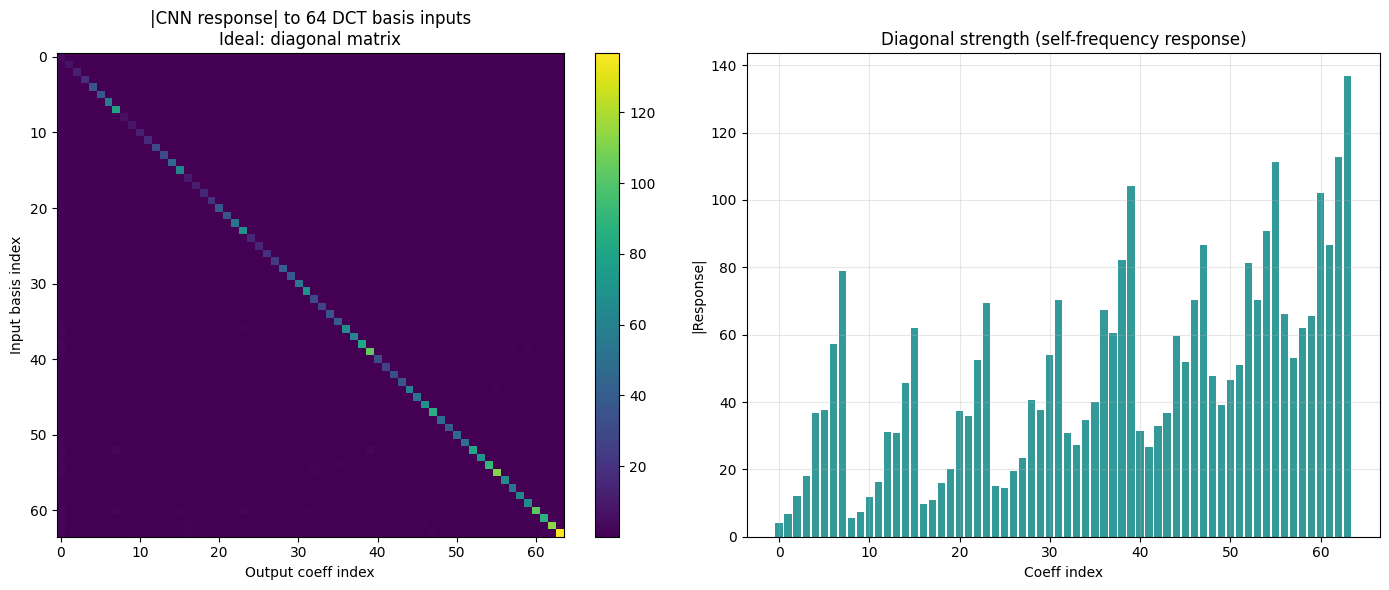

📊 Mean diagonal: 47.7258  |  DC response: 4.0707


In [17]:
# ============================================================
# LEARNED BASIS ANALYSIS
# ============================================================
def make_dct_basis(k, l, block=8):
    basis = np.zeros((block, block), dtype=np.float32)
    for x in range(block):
        for y in range(block):
            basis[x,y] = (np.cos(np.pi*k*(2*x+1)/(2*block)) *
                          np.cos(np.pi*l*(2*y+1)/(2*block)))
    mx = np.abs(basis).max()
    return basis / (mx + 1e-8)

model.eval()
responses = np.zeros((64,64), dtype=np.float32)
with torch.no_grad():
    for idx in range(64):
        k, l = divmod(idx, 8)
        basis = make_dct_basis(k, l, CONFIG['block_size'])
        inp = torch.from_numpy(basis).unsqueeze(0).unsqueeze(0).to(device)
        responses[idx] = model(inp).cpu().numpy().ravel()

fig, axes = plt.subplots(1, 2, figsize=(14,6))
im0 = axes[0].imshow(np.abs(responses), cmap='viridis', aspect='auto')
axes[0].set_title('|CNN response| to 64 DCT basis inputs\nIdeal: diagonal matrix')
axes[0].set_xlabel('Output coeff index'); axes[0].set_ylabel('Input basis index')
plt.colorbar(im0, ax=axes[0])
diag = np.diag(np.abs(responses))
axes[1].bar(range(64), diag, color='teal', alpha=.8)
axes[1].set_title('Diagonal strength (self-frequency response)')
axes[1].set_xlabel('Coeff index'); axes[1].set_ylabel('|Response|'); axes[1].grid(True, alpha=.3)
plt.tight_layout()
plt.savefig('learned_basis_analysis.png', dpi=150); plt.show()
print(f"📊 Mean diagonal: {diag.mean():.4f}  |  DC response: {diag[0]:.4f}")


In [ ]:
# ============================================================
# SAVE FINAL MODEL
# ============================================================

best_val = 0.000006

torch.save({
    'model_state': model.state_dict(),
    'coeff_mean' : train_ds.coeff_mean.tolist(),
    'coeff_std'  : train_ds.coeff_std.tolist(),
    'config'     : CONFIG,
    'best_val'   : best_val,
}, 'dct_replication_model.pth')

# ============================================================
# RESULTS
# ============================================================

cnn_p  = np.mean(results['cnn_dct']['psnr'])
true_p = np.mean(results['true_dct']['psnr'])
jpg_p  = np.mean(results['jpg_dct']['psnr'])

# ============================================================
# SUMMARY
# ============================================================

summary = f"""
DCT REPLICATION — FINAL SUMMARY
{'='*55}

Block size   : {CONFIG['block_size']}×{CONFIG['block_size']}
Image size   : {CONFIG['img_size']}×{CONFIG['img_size']}
Train patches: {len(train_ds):,}
Test patches : {len(test_ds):,}
Epochs       : {CONFIG['epochs']}
Best val MSE : {best_val:.6f}

PSNR (dB)

  True DCT (lossless) : {true_p:.4f}

  JPEG-DCT Q={CONFIG['dct_quality']} : {jpg_p:.4f}

  CNN DCT Replication : {cnn_p:.4f}

  Gap vs true DCT     : {cnn_p-true_p:+.3f}

  Gap vs JPEG-DCT     : {cnn_p-jpg_p:+.3f}

{'='*55}
"""

print(summary)

# ============================================================
# SAVE SUMMARY
# ============================================================

with open(
    'summary.txt',
    'w',
    encoding='utf-8'
) as f:
    f.write(summary)

print("✅ Saved: dct_replication_model.pth")
print("✅ Saved: summary.txt")


DCT REPLICATION — FINAL SUMMARY

Block size   : 8×8
Image size   : 128×128
Train patches: 384,512
Test patches : 55,040
Epochs       : 60
Best val MSE : 0.000006

PSNR (dB)

  True DCT (lossless) : 60.0000

  JPEG-DCT Q=50 : 31.0915

  CNN DCT Replication : 67.1621

  Gap vs true DCT     : +7.162

  Gap vs JPEG-DCT     : +36.071


✅ Saved: dct_replication_model.pth
✅ Saved: summary.txt


: 

## ✅ Done

See `visual_comparison.png`, `coefficient_fidelity.png`, `learned_basis_analysis.png`, `training_curve.png`, `summary.txt`.